# Meta-Analysis: Multi-Agent vs Single-Agent LLM Systems

**Notebook v8** 



## 1. Data
### 1.1 Setup and imports

In [ ]:
%matplotlib inline
import importlib, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path.cwd().parent))
import src.data_io, src.effect_sizes, src.pooling, src.heterogeneity
import src.publication_bias, src.sensitivity, src.plots, src.reporting
for mod in [src.data_io, src.effect_sizes, src.pooling, src.heterogeneity,
            src.publication_bias, src.sensitivity, src.plots, src.reporting]:
    importlib.reload(mod)

from src.data_io import load_verified, DATA_VERIFIED, REPORT_ASSETS
from src.effect_sizes import compute_effect_sizes, pooled_absolute_effect, n_items_provenance
from src.pooling import random_effects
from src.heterogeneity import leave_one_out
from src.publication_bias import egger_test, begg_test, trim_and_fill
from src.sensitivity import run_all_sensitivity
from src.plots import forest_plot, funnel_plot, prisma_flow
from src.reporting import format_pooled, descriptives_table, sensitivity_table, extraction_table

REPORT_ASSETS.mkdir(parents=True, exist_ok=True)
print("All modules loaded.")

All modules loaded.


### 1.2 Load verified data

In [ ]:
df = load_verified()
rob = pd.read_csv(DATA_VERIFIED / "risk-of-bias.csv")
with open(Path.cwd().parent / "data" / "extracted" / "prisma-counts.json") as f:
    prisma_counts = json.load(f)

print(f"Studies loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(5)

Studies loaded: 41
Columns: ['study-id', 'citation-key', 'year', 'backbone-model', 'architecture', 'n-agents', 'task-category', 'benchmark-name', 'n-items', 'n-correct-ma', 'n-correct-sa', 'compute-parity-flag', 'compute-ratio-ma-to-sa', 'source-table-or-figure', 'audit-status', 'n-items-estimated', 'metric-type', 'n-items-source']


,study-id,citation-key,year,backbone-model,architecture,n-agents,task-category,benchmark-name,n-items,n-correct-ma,n-correct-sa,compute-parity-flag,compute-ratio-ma-to-sa,source-table-or-figure,audit-status,n-items-estimated,metric-type,n-items-source
0,S001,Du2023,2023,ChatGPT (GPT-3.5),debate,3,math,GSM8K,1319,1121,1016,no,NR,Table/Fig from Du2023,unaudited,False,accuracy,exact
1,S002,Qian2024,2024,GPT-3.5-Turbo,role-play,3,code,SoftwareDev,70,1,1,no,NR,Table/Fig from Qian2024,unaudited,True,accuracy,imputed
2,S003,Liang2024,2024,GPT-3.5-Turbo,cooperation,3,evaluation,Counter-Intuitive AR,200,74,56,no,NR,Table/Fig from Liang2024,unaudited,True,accuracy,imputed
3,S004,Huang2024,2024,GPT-4,cooperation,3,code,HumanEval,164,158,148,no,NR,Table/Fig from Huang2024,unaudited,False,accuracy,exact
4,S005,Tian2025,2025,Gemini 2.5 Pro / GPT-5 / Grok 4 / Claude Sonnet 4,cooperation,3,other,GPQA-Diamond,198,172,170,no,NR,Table/Fig from Tian2025,verified,False,accuracy,exact


### 1.3 Effect sizes and descriptives

In [ ]:
df = compute_effect_sizes(df)
df["sa-accuracy"] = df["n-correct-sa"] / df["n-items"]
df["ma-accuracy"] = df["n-correct-ma"] / df["n-items"]
df["rd-pct"] = (df["ma-accuracy"] - df["sa-accuracy"]) * 100

print(f"Effect sizes computed for {len(df)} studies")
print(f"\nLog-OR: mean={df['yi'].mean():.3f}, median={df['yi'].median():.3f}, range=[{df['yi'].min():.3f}, {df['yi'].max():.3f}]")
print(f"Cohen's h: mean={df['h'].mean():.3f}")
print(f"Risk difference: mean={df['rd-pct'].mean():.1f}pp, median={df['rd-pct'].median():.1f}pp")
print(f"MA > SA: {(df['yi'] > 0).sum()}/41,  SA > MA: {(df['yi'] < 0).sum()}/41")
print(f"\nYear: {df['year'].value_counts().sort_index().to_dict()}")
print(f"Architecture: {df['architecture'].value_counts().to_dict()}")
print(f"Task: {df['task-category'].value_counts().to_dict()}")

Effect sizes computed for 41 studies

Log-OR: mean=0.512, median=0.365, range=[-2.296, 2.582]
Cohen's h: mean=0.199
Risk difference: mean=8.2pp, median=6.1pp
MA > SA: 37/41,  SA > MA: 3/41

Year: {2023: 1, 2024: 11, 2025: 16, 2026: 13}
Architecture: {'debate': 20, 'cooperation': 9, 'hierarchy': 6, 'role-play': 2, 'verifier-critic': 2, 'planner-executor': 1, 'moa': 1}
Task: {'code': 11, 'other': 10, 'medical': 7, 'math': 6, 'evaluation': 3, 'general-knowledge': 3, 'factuality': 1}


### 1.5 PRISMA flow

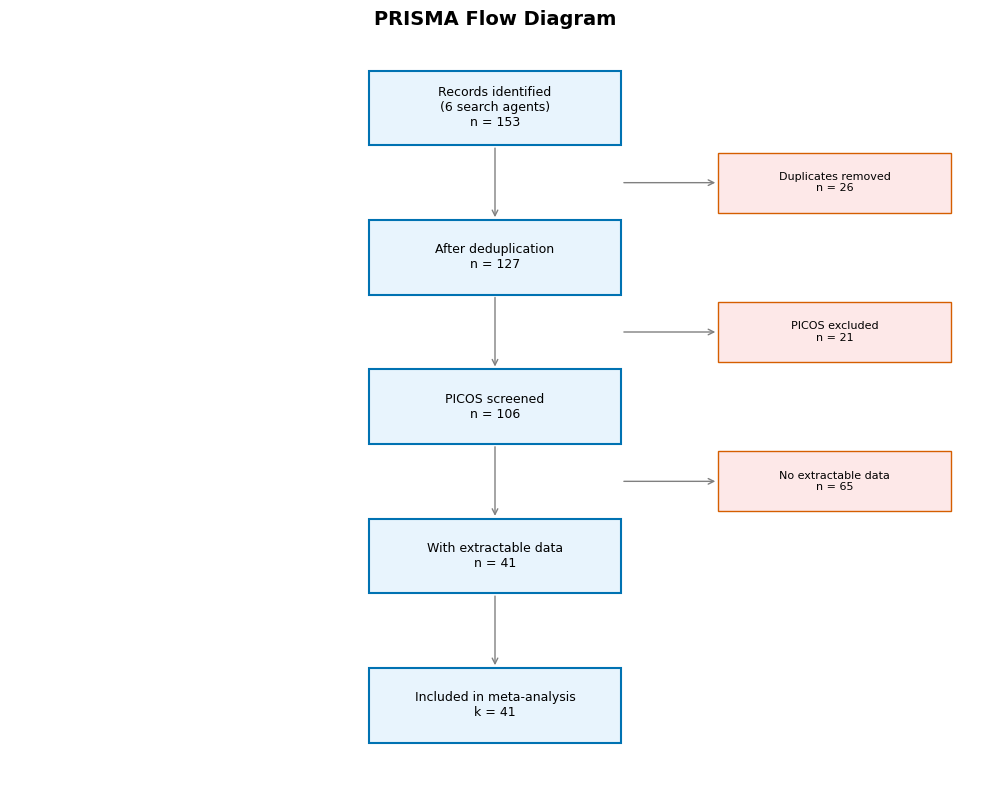

In [ ]:
fig_prisma = prisma_flow(prisma_counts)
plt.show()

## 2. Pooled Analysis
### 2.1 REML and DerSimonian-Laird estimates

In [ ]:
yi, vi = df["yi"].values, df["vi"].values
res_reml = random_effects(yi, vi, method="reml")
res_dl = random_effects(yi, vi, method="dl")

print("=== REML Random-Effects (full sample, k=41) ===")
print(format_pooled(res_reml))
print(f"OR = {np.exp(res_reml['pooled-lor']):.2f}")

# v7 (review M1): absolute-scale effects are now COMPUTED here, not hand-entered.
print("\n=== Absolute-scale effect (computed in-pipeline) ===")
abs_full = pooled_absolute_effect(df["n-correct-ma"], df["n-correct-sa"], df["n-items"])
print(f"Aggregate proportions: MA {abs_full['p-ma']*100:.1f}% vs SA {abs_full['p-sa']*100:.1f}%")
print(f"Risk difference: {abs_full['rd-agg-pp']:.1f} pp aggregate/n-weighted | "
      f"{abs_full['rd-mean-pp']:.1f} pp unweighted mean | {abs_full['rd-median-pp']:.1f} pp median")
print(f"Cohen's h: {abs_full['h-agg']:.3f} aggregate | {abs_full['h-mean']:.3f} unweighted mean  (both 'small'/'trivial')")

print("\n=== DerSimonian-Laird (sensitivity) ===")
print(format_pooled(res_dl))
print(f"\nQ identical across estimators: {abs(res_reml['q'] - res_dl['q']) < 1e-10}")
pooled = res_reml

=== REML Random-Effects (full sample, k=41) ===
LOR = 0.45, 95% CI [0.23, 0.67], 95% PI [-0.74, 1.64], τ² = 0.335, I² = 96%, Q(40) = 1016.6, p = 0.0000
OR = 1.57

=== Absolute-scale effect (computed in-pipeline) ===
Aggregate proportions: MA 74.1% vs SA 71.1%
Risk difference: 2.9 pp aggregate/n-weighted | 8.2 pp unweighted mean | 6.1 pp median
Cohen's h: 0.066 aggregate | 0.199 unweighted mean  (both 'small'/'trivial')

=== DerSimonian-Laird (sensitivity) ===
LOR = 0.41, 95% CI [0.22, 0.61], 95% PI [-0.38, 1.21], τ² = 0.145, I² = 96%, Q(40) = 1016.6, p = 0.0000

Q identical across estimators: True


### 2.2 Forest plot

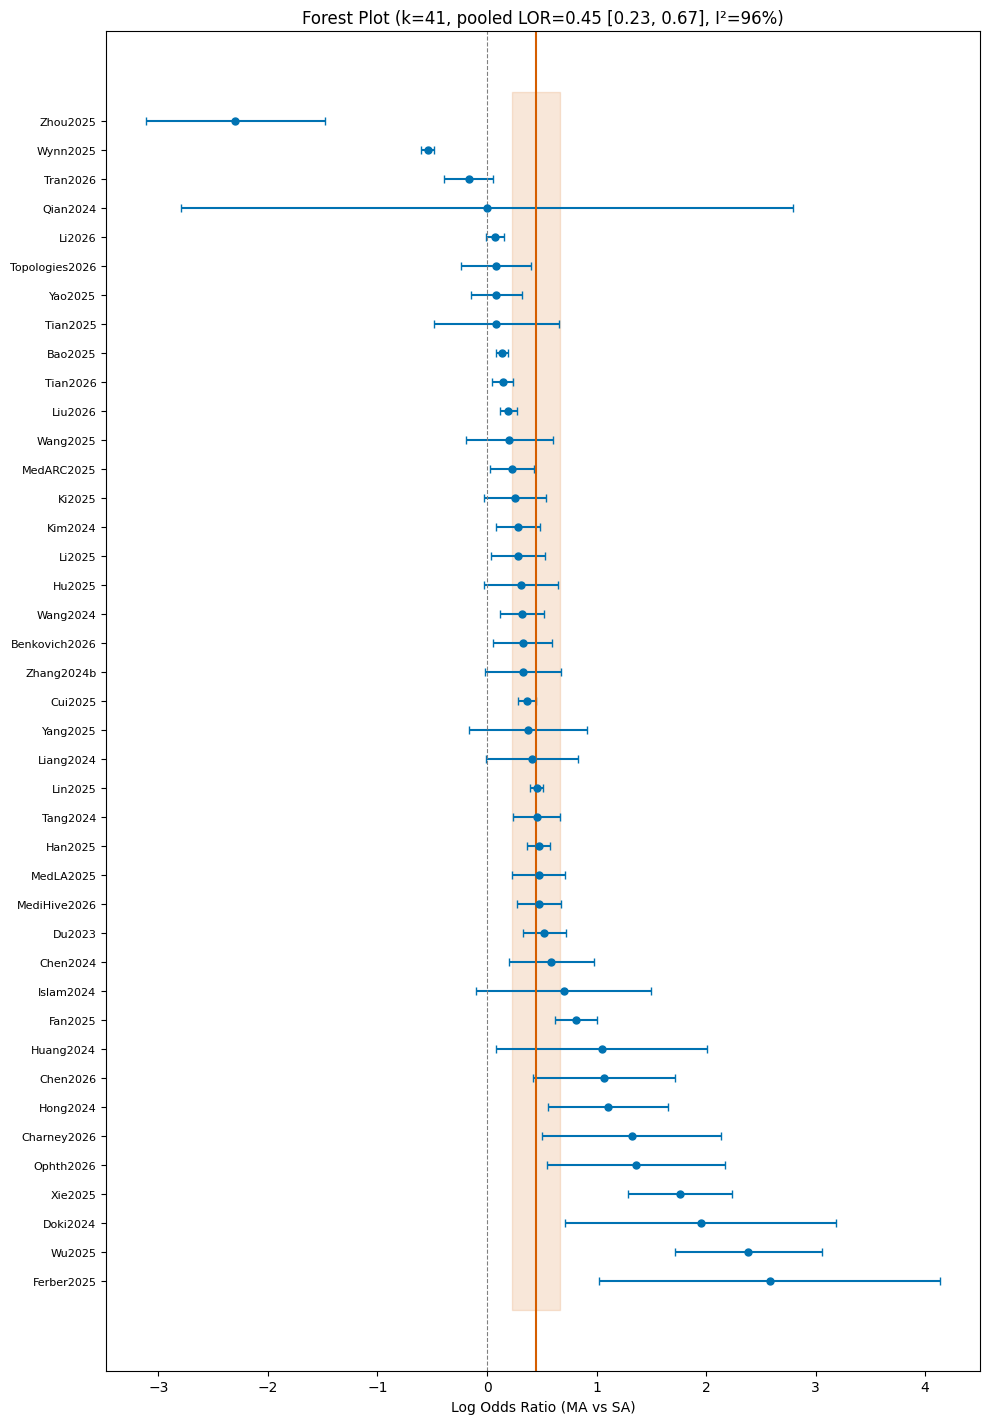

In [ ]:
fig_forest = forest_plot(df.sort_values("yi"), pooled, save=True)
plt.show()

### 2.3 Leave-one-out

Leave-one-out range: [0.396, 0.476]
Most influential: Wu2025 -> LOR=0.396


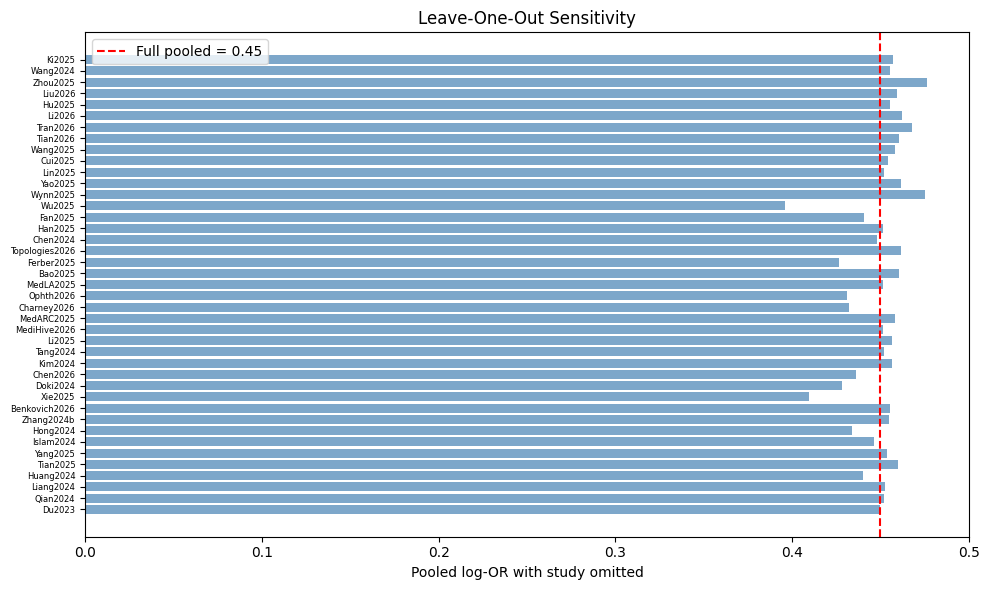

In [ ]:
loo = leave_one_out(yi, vi)
loo["citation-key"] = df["citation-key"].values
print(f"Leave-one-out range: [{loo['mu'].min():.3f}, {loo['mu'].max():.3f}]")
most = loo.loc[loo["mu"].idxmin()]
print(f"Most influential: {most['citation-key']} -> LOR={most['mu']:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(loo)), loo["mu"], color="steelblue", alpha=0.7)
ax.axvline(pooled["pooled-lor"], color="red", ls="--", label=f"Full pooled = {pooled['pooled-lor']:.2f}")
ax.set_yticks(range(len(loo)))
ax.set_yticklabels(loo["citation-key"], fontsize=6)
ax.set_xlabel("Pooled log-OR with study omitted")
ax.set_title("Leave-One-Out Sensitivity")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Robustness

P-curve removed (reviewer issue #9). All diagnostics are exploratory and unreliable under extreme heterogeneity.

### 3.1 Publication bias

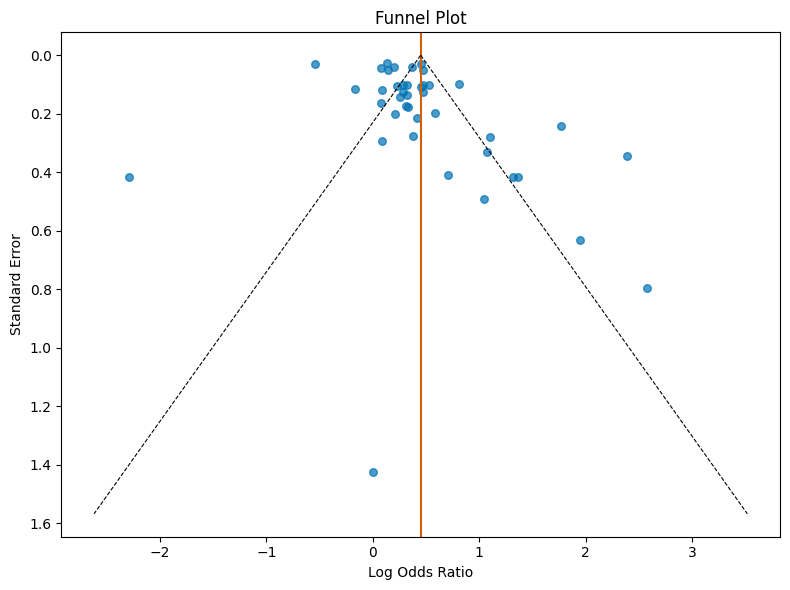

Egger's test: intercept = 2.526, t(39) = 2.343, p = 0.0243
=> SIGNIFICANT funnel asymmetry

Begg's test: tau = 0.056, p = 0.6054
Trim-and-fill: 0 studies imputed, adjusted LOR = 0.450


In [ ]:
fig_funnel = funnel_plot(df, pooled)
plt.show()

egger = egger_test(yi, df["sei"].values)
print(f"Egger's test: intercept = {egger['intercept']:.3f}, t({egger['df']}) = {egger['t']:.3f}, p = {egger['p']:.4f}")
print(f"=> {'SIGNIFICANT' if egger['p'] < 0.05 else 'not significant'} funnel asymmetry")

begg = begg_test(yi, vi)
print(f"\nBegg's test: tau = {begg['tau']:.3f}, p = {begg['p']:.4f}")

tf = trim_and_fill(yi, vi)
print(f"Trim-and-fill: {tf['k0']} studies imputed, adjusted LOR = {tf['pooled-lor-adj']:.3f}")

### 3.2 Sensitivity analyses

In [ ]:
sens = run_all_sensitivity(df, rob)
print(sensitivity_table(sens))

| label                     |   k |   pooled-lor |   ci-lo |   ci-hi | i2   |
|:--------------------------|----:|-------------:|--------:|--------:|:-----|
| Full sample               |  41 |         0.45 |    0.23 |    0.67 | 96%  |
| Compute-parity only       |   9 |         0.31 |    0.01 |    0.61 | 85%  |
| 2025+ only                |  29 |         0.41 |    0.1  |    0.71 | 97%  |
| High-RoB removed          |  16 |         0.42 |    0.13 |    0.72 | 86%  |
| Verified studies only     |  10 |         0.35 |    0.19 |    0.51 | 54%  |
| Non-aggregated benchmarks |  36 |         0.48 |    0.23 |    0.74 | 96%  |
| Accuracy metrics only     |  37 |         0.46 |    0.22 |    0.71 | 96%  |
| Exact n-items only        |  28 |         0.4  |    0.13 |    0.67 | 97%  |
| Unverifiable removed      |  39 |         0.43 |    0.2  |    0.65 | 96%  |


> **Key findings (v8):** Compute-parity (k=9) attenuates the *relative* effect ~31% (log-OR 0.45→0.31), but the *absolute* gain does **not** shrink (aggregate RD ≈ 5 pp vs ≈ 3 pp full-sample; the parity subset excludes the large near-null general-knowledge benchmarks). Verified/source-located subset (k=10) shows τ²=0.01 — the credibility anchor. Accuracy-only (k=37) is the primary item-level binomial spec (0.46 [0.22, 0.71]). No single-study removal reverses sign.

### 3.3 Full extraction table (41 rows)

In [ ]:
# v7 (review V3): honest denominator provenance, computed (supersedes the overloaded n-items-source).
df["n-items-provenance"] = [n_items_provenance(a, s) for a, s in zip(df["audit-status"], df["n-items-source"])]
print("n-items provenance:", df["n-items-provenance"].value_counts().to_dict())

ext_table = extraction_table(df, rob)
ext_table["n-items-provenance"] = df["n-items-provenance"].values
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 22)
pd.set_option("display.width", 220)
ext_table

n-items provenance: {'benchmark-imputed': 30, 'paper-audited': 10, 'percent-estimated': 1}


,study-id,citation-key,benchmark-name,task-category,architecture,n-items,n-correct-ma,n-correct-sa,n-items-source,compute-parity-flag,audit-status,rob-overall,yi,vi,h,ma-pct,sa-pct,rd-pct,n-items-provenance
0,S001,Du2023,GSM8K,math,debate,1319,1121,1016,exact,no,unaudited,high,0.524,0.0102,0.204,85.0,77.0,8.0,benchmark-imputed
1,S002,Qian2024,SoftwareDev,code,role-play,70,1,1,imputed,no,unaudited,high,0.000,2.0290,0.000,1.4,1.4,0.0,benchmark-imputed
2,S003,Liang2024,Counter-Intuitive AR,evaluation,cooperation,200,74,56,imputed,no,unaudited,high,0.412,0.0463,0.193,37.0,28.0,9.0,benchmark-imputed
3,S004,Huang2024,HumanEval,code,cooperation,164,158,148,exact,no,unaudited,high,1.046,0.2423,0.250,96.3,90.2,6.1,benchmark-imputed
4,S005,Tian2025,GPQA-Diamond,other,cooperation,198,172,170,exact,no,verified,high,0.086,0.0859,0.029,86.9,85.9,1.0,paper-audited
5,S006,Yang2025,HumanEval,code,cooperation,164,135,125,exact,unclear,unaudited,some,0.373,0.0755,0.151,82.3,76.2,6.1,benchmark-imputed
6,S007,Islam2024,HumanEval,code,planner-executor,164,154,145,exact,no,verified-corrected,high,0.702,0.1660,0.196,93.9,88.4,5.5,paper-audited
7,S008,Hong2024,HumanEval,code,hierarchy,164,141,110,exact,no,unaudited,high,1.102,0.0782,0.455,86.0,67.1,18.9,benchmark-imputed
8,S009,Zhang2024b,SWE-bench Lite,code,cooperation,300,103,82,exact,unclear,verified-corrected,some,0.329,0.0316,0.152,34.3,27.3,7.0,paper-audited
9,S010,Benkovich2026,SWE-bench 500,code,role-play,500,360,325,exact,yes,unaudited,some,0.325,0.0187,0.151,72.0,65.0,7.0,benchmark-imputed


## 4. Export & Validation
### 4.1 Export all assets

In [ ]:
# v7 (review M1): write pooled absolute effects into results-summary.json so the report traces to code.
cp = df["compute-parity-flag"] == "yes"
acc = df["metric-type"] == "accuracy"
absolute = {
    "full": pooled_absolute_effect(df["n-correct-ma"], df["n-correct-sa"], df["n-items"]),
    "accuracy-only": pooled_absolute_effect(df.loc[acc, "n-correct-ma"], df.loc[acc, "n-correct-sa"], df.loc[acc, "n-items"]),
    "compute-parity": pooled_absolute_effect(df.loc[cp, "n-correct-ma"], df.loc[cp, "n-correct-sa"], df.loc[cp, "n-items"]),
}
results_summary = {
    "reml": res_reml, "dl": res_dl,
    "egger": egger, "begg": begg,
    "trim-and-fill": tf,
    "absolute": absolute,
}
with open(REPORT_ASSETS / "results-summary.json", "w") as f:
    json.dump(results_summary, f, indent=2, default=float)

descriptives_table(df).to_csv(REPORT_ASSETS / "descriptives.csv")
sens.to_csv(REPORT_ASSETS / "sensitivity.csv", index=False)
ext_table.to_csv(REPORT_ASSETS / "extraction-table.csv", index=False)

print(f"Exported to {REPORT_ASSETS}")
print(f"Full sample: RD_agg={absolute['full']['rd-agg-pp']:.1f}pp h_agg={absolute['full']['h-agg']:.3f} | "
      f"compute-parity: RD_agg={absolute['compute-parity']['rd-agg-pp']:.1f}pp h_agg={absolute['compute-parity']['h-agg']:.3f}")
print(f"Data: {sorted(f.name for f in REPORT_ASSETS.glob('*.csv'))}")

Exported to /Users/veto/Documents/git/Proj-Meta/report/assets
Full sample: RD_agg=2.9pp h_agg=0.066 | compute-parity: RD_agg=5.1pp h_agg=0.105
Data: ['descriptives.csv', 'extraction-table.csv', 'meta-regression.csv', 'sensitivity.csv', 'subgroup-arch.csv', 'subgroup-task.csv']


### 4.2 Validation

In [ ]:
checks = [
    (res_reml["k"] == 41, f"k should be 41, got {res_reml['k']}"),
    (res_reml["df"] == 40, f"df should be 40, got {res_reml['df']}"),
    (res_reml["q"] > 0, f"Q should be positive"),
    (0 < res_reml["i2"] <= 100, f"I² out of range"),
    (res_reml["tau2"] >= 0, f"tau² negative"),
    (res_reml["ci-lo"] < res_reml["pooled-lor"] < res_reml["ci-hi"], "CI doesn't bracket pooled"),
    (res_reml["pi-lo"] < res_reml["pooled-lor"] < res_reml["pi-hi"], "PI doesn't bracket pooled"),
    (egger["df"] == 39, f"Egger df should be 39, got {egger['df']}"),
    # v7 regression guards: report's absolute numbers must equal pipeline output
    (round(absolute["full"]["h-agg"], 2) == 0.07, f"full aggregate h drifted: {absolute['full']['h-agg']:.3f}"),
    (round(absolute["full"]["rd-agg-pp"]) == 3, f"full aggregate RD drifted: {absolute['full']['rd-agg-pp']:.1f}"),
    (absolute["compute-parity"]["rd-agg-pp"] > absolute["full"]["rd-agg-pp"], "parity RD should NOT be < full (scale divergence)"),
    # v7 provenance: paper-audited can never co-occur with unaudited/estimated
    (df["n-items-provenance"].eq("paper-audited").sum() == 10, f"paper-audited count: {df['n-items-provenance'].eq('paper-audited').sum()}"),
]
failed = [msg for ok, msg in checks if not ok]
if failed:
    print(f"VALIDATION FAILED: {failed}")
else:
    print(f"All {len(checks)} validation checks passed.")

All 12 validation checks passed.
